Import all necessary libraries.

In [1]:
import pandas as pd
import numpy as np
import os
import wandb
import random
import torch
import torch.nn as nn
from torch.nn.utils import clip_grad_norm_
from torch.utils.data import DataLoader
from imblearn.metrics import geometric_mean_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix
import seaborn as sns

import sys
sys.path.append(os.path.join(os.getcwd(), '../src'))

from transforms.feature_engineering_classification import add_all_features, filter_business_hours, entries_per_day_per_site
from transforms.feature_engineering_classification import (
    CONTINUOUS_FEATURE_COLUMNS,
    CATEGORICAL_FEATURE_COLUMNS,
    CYCLIC_FEATURE_COLUMNS,
    TARGET_COLUMN
)
from evaluation.comp_metrics import evaluate_all_metrics
from evaluation.visual import plot_confusion_matrix

from datasets.flextrack_dataset import FlextrackClassificationDataset
from utils.losses import FocalLoss

c:\Users\timon\.pyenv-win-venv\envs\aicomp\Lib\site-packages\pydantic\_internal\_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
c:\Users\timon\.pyenv-win-venv\envs\aicomp\Lib\site-packages\pydantic\_internal\_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because a

Set seed for reproducibility.

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
os.environ["WANDB_API_KEY"] = "3aaf9f796df65417b3f5f8560b43875171b55805"

wandb.login()

wandb: Currently logged in as: fabian-dubach (fabian-dubach-hochschule-luzern) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [4]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [5]:
# just use regression data and remove DR-Flags and DR-Capacity
df_train = pd.read_csv(os.path.normpath(os.path.join(os.getcwd(), '../data/regression/regression-train.csv')))
df_test = pd.read_csv(os.path.normpath(os.path.join(os.getcwd(), '../data/regression/regression-test.csv')))

In [6]:
print(f"Dataset shape: {df_train.shape}")
print(f"\nColumns: {df_train.columns.tolist()}")

Dataset shape: (105120, 7)

Columns: ['Site', 'Timestamp_Local', 'Dry_Bulb_Temperature_C', 'Global_Horizontal_Radiation_W/m2', 'Building_Power_kW', 'Demand_Response_Flag', 'Demand_Response_Capacity_kW']


# Feature Engineering

We use same feature engineering as in regression task but remove the irrelevant features.

In [7]:
df_train = add_all_features(df_train)

df_train = filter_business_hours(df_train)

ENTRIES_PER_DAY = entries_per_day_per_site(df_train)

In [8]:
print(f"Dataset shape: {df_train.shape}")
print(f"\nColumns: {df_train.columns.tolist()}")

Dataset shape: (58035, 40)

Columns: ['Site', 'Timestamp_Local', 'Dry_Bulb_Temperature_C', 'Global_Horizontal_Radiation_W/m2', 'Building_Power_kW', 'Demand_Response_Flag', 'Demand_Response_Capacity_kW', 'hour', 'minute', 'day_of_week', 'is_weekend', 'is_holiday', 'month_sin', 'month_cos', 'Building_Power_kW_diff_15min', 'Building_Power_kW_diff_1h', 'Building_Power_kW_diff_1d', 'Dry_Bulb_Temperature_C_diff_15min', 'Global_Horizontal_Radiation_W/m2_diff_15min', 'Building_Power_kW_rolling_mean_1h', 'Building_Power_kW_rolling_mean_2h', 'Building_Power_kW_rolling_mean_1d', 'Building_Power_kW_rolling_std_1h', 'Building_Power_kW_rolling_std_2h', 'Building_Power_kW_rolling_std_1d', 'Building_Power_kW_rolling_min_1h', 'Building_Power_kW_rolling_min_2h', 'Building_Power_kW_rolling_max_1h', 'Building_Power_kW_rolling_max_2h', 'minute_0', 'minute_15', 'minute_30', 'minute_45', 'day_of_week_0', 'day_of_week_1', 'day_of_week_2', 'day_of_week_3', 'day_of_week_4', 'day_of_week_5', 'day_of_week_6']


# Split sites

In [9]:
def count_sites(df):

    counter_site_a = 0
    counter_site_b = 0
    counter_site_c = 0
    counter_site_d = 0
    counter_site_e = 0

    for i in df['Site']:
        if i == 'siteA':
            counter_site_a += 1
        elif i == 'siteB':
            counter_site_b += 1
        elif i == 'siteC':
            counter_site_c += 1
        elif i == 'siteD':
            counter_site_d += 1
        elif i == 'siteE':
            counter_site_e += 1
    
    return counter_site_a, counter_site_b, counter_site_c, counter_site_d, counter_site_e

In [10]:
df_train_site_a = df_train[0:19345]
count_sites(df_train_site_a)

df_train_site_b = df_train[19345:38690]
count_sites(df_train_site_b)

df_train_site_c = df_train[38690:58035]
count_sites(df_train_site_c)

(0, 0, 19345, 0, 0)

In [11]:
X_continuous_site_a = df_train_site_a[CONTINUOUS_FEATURE_COLUMNS].values # Convert to numpy array
X_continuous_site_b = df_train_site_b[CONTINUOUS_FEATURE_COLUMNS].values # Convert to numpy array
X_continuous_site_c = df_train_site_c[CONTINUOUS_FEATURE_COLUMNS].values # Convert to numpy array

X_categorical_site_a = df_train_site_a[CATEGORICAL_FEATURE_COLUMNS].values # Convert to numpy array
X_categorical_site_b = df_train_site_b[CATEGORICAL_FEATURE_COLUMNS].values # Convert to numpy array
X_categorical_site_c = df_train_site_c[CATEGORICAL_FEATURE_COLUMNS].values # Convert to numpy array

X_cyclic_site_a = df_train_site_a[CYCLIC_FEATURE_COLUMNS].values # Convert to numpy array
X_cyclic_site_b = df_train_site_b[CYCLIC_FEATURE_COLUMNS].values # Convert to numpy array
X_cyclic_site_c = df_train_site_c[CYCLIC_FEATURE_COLUMNS].values # Convert to numpy array

y_site_a = df_train_site_a[TARGET_COLUMN].values.reshape(-1, 1) # Convert to numpy array and reshape
y_site_b = df_train_site_b[TARGET_COLUMN].values.reshape(-1, 1) # Convert to numpy array and reshape
y_site_c = df_train_site_c[TARGET_COLUMN].values.reshape(-1, 1) # Convert to numpy array and reshape

In [12]:
print(f"Continuous feature shape: {X_continuous_site_a.shape}")
print(f"Continuous feature shape: {X_continuous_site_b.shape}")
print(f"Continuous feature shape: {X_continuous_site_c.shape}")

print(f"Categorical feature shape: {X_categorical_site_a.shape}")
print(f"Categorical feature shape: {X_categorical_site_b.shape}")
print(f"Categorical feature shape: {X_categorical_site_c.shape}")

print(f"Cyclic feature shape: {X_cyclic_site_a.shape}")
print(f"Cyclic feature shape: {X_cyclic_site_b.shape}")
print(f"Cyclic feature shape: {X_cyclic_site_c.shape}")

print(f"Target shape: {y_site_a.shape}")
print(f"Target shape: {y_site_b.shape}")
print(f"Target shape: {y_site_c.shape}")

Continuous feature shape: (19345, 19)
Continuous feature shape: (19345, 19)
Continuous feature shape: (19345, 19)
Categorical feature shape: (19345, 13)
Categorical feature shape: (19345, 13)
Categorical feature shape: (19345, 13)
Cyclic feature shape: (19345, 2)
Cyclic feature shape: (19345, 2)
Cyclic feature shape: (19345, 2)
Target shape: (19345, 1)
Target shape: (19345, 1)
Target shape: (19345, 1)


In [13]:
y_site_a_unscaled = y_site_a.copy()

# Normalization

In [14]:
scaler_X_site_a = StandardScaler()
scaler_X_site_b = StandardScaler()
scaler_X_site_c = StandardScaler()

In [15]:
X_scaled_site_a = scaler_X_site_a.fit_transform(X_continuous_site_a)
X_scaled_site_b = scaler_X_site_b.fit_transform(X_continuous_site_b)
X_scaled_site_c = scaler_X_site_c.fit_transform(X_continuous_site_c)

Concatenate the unscaled and the scaled features together.

In [16]:
X_site_a = np.concatenate([X_scaled_site_a, X_categorical_site_a, X_cyclic_site_a], axis=1)
X_site_b = np.concatenate([X_scaled_site_b, X_categorical_site_b, X_cyclic_site_b], axis=1)
X_site_c = np.concatenate([X_scaled_site_c, X_categorical_site_c, X_cyclic_site_c], axis=1)

In [17]:
X_site_a = X_site_a.astype(np.float32)
X_site_b = X_site_b.astype(np.float32)
X_site_c = X_site_c.astype(np.float32)

y_site_a = y_site_a.astype(int)
y_site_b = y_site_b.astype(int)
y_site_c = y_site_c.astype(int)

In [18]:
print(f"Continuous feature shape: {X_site_a.shape}")
print("First few entries of each site have nan values due to feature engineering:\n", X_site_a[0])
print(X_site_a[ENTRIES_PER_DAY])

Continuous feature shape: (19345, 34)
First few entries of each site have nan values due to feature engineering:
 [ 0.57910997 -1.3638599  -0.5221737  -0.00325376 -0.00751908         nan
 -0.69390106  0.0624692  -0.54411376 -0.5452835          nan -0.64983785
 -0.84162885         nan -0.38954532 -0.25569385 -0.6574576  -0.75812143
 -1.602483    1.          0.          0.          0.          0.
  1.          0.          0.          0.          0.          0.
  0.          1.          0.5         0.8660254 ]
[ 3.1494236e-01 -1.3638599e+00 -5.2217370e-01 -3.2537556e-03
 -7.5190784e-03  9.0518305e-03 -3.7747535e-01  6.2469199e-02
 -5.4411376e-01 -5.4528350e-01  2.9363585e+00 -6.4983785e-01
 -8.4162885e-01  4.3428288e+00 -3.8954532e-01 -2.5569385e-01
 -6.5745759e-01 -7.5812143e-01 -1.6024830e+00  1.0000000e+00
  0.0000000e+00  0.0000000e+00  0.0000000e+00  0.0000000e+00
  0.0000000e+00  1.0000000e+00  0.0000000e+00  0.0000000e+00
  0.0000000e+00  0.0000000e+00  0.0000000e+00  0.0000000e+00

In [19]:
np.unique(y_site_a)

array([0, 1, 2])

IMPORTANT: Remove entries, where features are incomplete (at start of dataset)

In [20]:
# Create mask to exclude first ENTRIES_PER_DAY of each site
mask_site_a = np.ones(len(X_site_a), dtype=bool)
mask_site_b = np.ones(len(X_site_b), dtype=bool)
mask_site_c = np.ones(len(X_site_c), dtype=bool)

# Site A: exclude indices 0 to ENTRIES_PER_DAY-1
mask_site_a[0:ENTRIES_PER_DAY] = False

# Site B: exclude indices (365*ENTRIES_PER_DAY) to (365*ENTRIES_PER_DAY + ENTRIES_PER_DAY-1)
mask_site_b[0:ENTRIES_PER_DAY] = False

# Site C: exclude indices (730*ENTRIES_PER_DAY) to (730*ENTRIES_PER_DAY + ENTRIES_PER_DAY-1)
mask_site_c[0:ENTRIES_PER_DAY] = False

# Apply mask to remove incomplete entries
X_site_a = X_site_a[mask_site_a]
X_site_b = X_site_b[mask_site_b]
X_site_c = X_site_c[mask_site_c]

y_site_a = y_site_a[mask_site_a]
y_site_b = y_site_b[mask_site_b]
y_site_c = y_site_c[mask_site_c]

### Data Splitting

In [21]:
# Calculate split indices (accounting for removed incomplete entries)
site_a_entries = (365 - 1) * ENTRIES_PER_DAY  # 364 days of site A
site_b_entries = (365 - 1) * ENTRIES_PER_DAY  # 364 days of site B

# Train on Site A and Site C, validate on Site B
X_train = np.vstack((X_site_a, X_site_c))
X_val = X_site_b
y_train = np.vstack((y_site_a, y_site_c))
y_val = y_site_b

In [22]:
print(len(X_train))
print(len(y_train))
print(len(X_val))
print(len(y_val))

38584
38584
19292
19292


## Prepare Sequences

In [23]:
config = {
    # Model hyperparameters
    'input_size': X_train.shape[1],
    'hidden_size': 64,
    'num_layers': 2,
    'dropout': 0.1207622328018408,
    'sequence_length': 12,
    
    # Training hyperparameters
    'learning_rate': 0.0013396001126379316,
    'weight_decay': 1e-5,
    'batch_size': 32,
    'num_epochs': 50,
    'gradient_clip_val': 1.0,
    'warmup_epochs': 5,
    'optimizer': 'Adam',

    # Loss Function Parameters
    'loss_function': 'FocalLoss',
    'focal_alpha': 1,
    'focal_gamma': 2,
    
    # Model architecture
    'model_type': 'LSTM'
}

Create sequences to create a "sliding window" for the RNN architechture to predict the current hidden state based on the past values.

In [24]:
def create_sequences(X, y, seq_length=config['sequence_length']):
    sequences_X = []
    sequences_y = []
    
    for i in range(len(X) - seq_length):
        sequences_X.append(X[i:i+seq_length])
        sequences_y.append(y[i+seq_length])
    
    return np.array(sequences_X), np.array(sequences_y)

In [25]:
X_train_seq_a, y_train_seq_a = create_sequences(X_site_a, y_site_a)
X_train_seq_c, y_train_seq_c = create_sequences(X_site_c, y_site_c)
X_val_seq, y_val_seq = create_sequences(X_val, y_val)

X_train_seq = np.vstack((X_train_seq_a, X_train_seq_c))
y_train_seq = np.vstack((y_train_seq_a, y_train_seq_c))

In [26]:
print(f"Training sequences shape: {X_train_seq_a.shape}, Training targets shape: {y_train_seq_a.shape}")
print(f"Training sequences shape: {X_train_seq_c.shape}, Training targets shape: {y_train_seq_c.shape}")
print(f"Validation sequences shape: {X_val_seq.shape}, Validation targets shape: {y_val_seq.shape}")
print(f"Training sequences shape: {X_train_seq.shape}, Training targets shape: {y_train_seq.shape}")

Training sequences shape: (19280, 12, 34), Training targets shape: (19280, 1)
Training sequences shape: (19280, 12, 34), Training targets shape: (19280, 1)
Validation sequences shape: (19280, 12, 34), Validation targets shape: (19280, 1)
Training sequences shape: (38560, 12, 34), Training targets shape: (38560, 1)


In [27]:
np.unique(y_train_seq)

array([0, 1, 2])

Create DataLoader -> DataLoader's job: Efficiently load data in batches during training

In [28]:
train_dataset = FlextrackClassificationDataset(X_train_seq, y_train_seq)
val_dataset = FlextrackClassificationDataset(X_val_seq, y_val_seq)

batch_size = config['batch_size']
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

Create a simple RNN architecture.

Why not use nn.RNN: nn.RNN is just the recurrent layer - it's not a complete model. You need additional components to make predictions.

In [29]:
class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes=3,
                 dropout=0.2, bidirectional=False):
        super().__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional,
        )
        
        lstm_output_size = hidden_size * (2 if bidirectional else 1)

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(lstm_output_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, num_classes)
        )
    
    def forward(self, x):
        # x: (batch, seq_len, input_size)
        out, (h_n, c_n) = self.lstm(x)
        
        # last time step, last layer
        if self.bidirectional:
            last_hidden = torch.cat((h_n[-2], h_n[-1]), dim=1)
        else:
            last_hidden = h_n[-1]
        
        logits = self.classifier(last_hidden)
        return logits


Define hyperparameters for the model.

Define cuda as the device to make the training possible to the GPU.

In [30]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


Generate model.

In [31]:
model = LSTMClassifier(config['input_size'], config['hidden_size'], config['num_layers'], dropout=config['dropout']).to(device)
print(f"Model architecture:\n{model}")

Model architecture:
LSTMClassifier(
  (lstm): LSTM(34, 64, num_layers=2, batch_first=True, dropout=0.1207622328018408)
  (classifier): Sequential(
    (0): Dropout(p=0.1207622328018408, inplace=False)
    (1): Linear(in_features=64, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.1207622328018408, inplace=False)
    (4): Linear(in_features=64, out_features=3, bias=True)
  )
)


Setup the loss function and optimizer.

In [32]:
# weighted loss
criterion = FocalLoss(alpha=config['focal_alpha'], gamma=config['focal_gamma'])

optimizer = torch.optim.Adam(model.parameters(), lr=config['learning_rate'], weight_decay=config['weight_decay'])

In [33]:
# Start a new wandb run to track this script.
wandb.init(
    # Set the wandb entity where your project will be logged (generally your team name).
    entity="fabian-dubach-hochschule-luzern",
    # Set the wandb project where this run will be logged.
    project="AICOMP_Flextrack",
    # Name this run
    name=config['model_type'].lower() + "-classification",
    # Track hyperparameters and run metadata.
    config=config
)

print("WandB initialized successfully!")

WandB initialized successfully!


# Training

In [34]:
# Warmup scheduler function
def get_lr_with_warmup(epoch, base_lr, warmup_epochs):
    """
    Calculate learning rate with linear warmup
    
    Args:
        epoch: Current epoch (0-indexed)
        base_lr: Target learning rate after warmup
        warmup_epochs: Number of epochs for warmup
    
    Returns:
        Current learning rate
    """
    if warmup_epochs == 0 or epoch >= warmup_epochs:
        return base_lr
    else:
        # Linear warmup from 0 to base_lr
        return base_lr * (epoch + 1) / warmup_epochs

In [35]:
train_losses = []
val_losses = []
best_val_loss = float('inf')

print("Starting training...")
print(f"Warmup enabled: {config['warmup_epochs']} epochs")

for epoch in range(config['num_epochs']):

    # ============== LEARNING RATE WARMUP ==============
    current_lr = get_lr_with_warmup(
        epoch,
        config['learning_rate'],
        config['warmup_epochs']
    )

    for param_group in optimizer.param_groups:
        param_group['lr'] = current_lr

    # ============== TRAINING ==============
    model.train()
    train_loss = 0
    train_preds = []
    train_targets = []

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # Forward
        logits = model(X_batch)  # shape: (batch, 3)
        loss = criterion(logits, y_batch)  # CE expects integer labels

        # Backward
        optimizer.zero_grad()
        loss.backward()
        clip_grad_norm_(model.parameters(), config['gradient_clip_val'])
        optimizer.step()

        train_loss += loss.item()

        # Store predictions + targets
        preds = torch.argmax(logits, dim=1)
        train_preds.append(preds.cpu().numpy())
        train_targets.append(y_batch.cpu().numpy())

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    train_preds = np.concatenate(train_preds)
    train_targets = np.concatenate(train_targets)

    # Classification metrics
    train_gmean = geometric_mean_score(train_targets, train_preds)
    train_f1 = f1_score(train_targets, train_preds, average="macro")

    # ============== VALIDATION ==============
    model.eval()
    val_loss = 0
    val_preds = []
    val_targets = []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            val_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            val_preds.append(preds.cpu().numpy())
            val_targets.append(y_batch.cpu().numpy())

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    val_preds = np.concatenate(val_preds)
    val_targets = np.concatenate(val_targets)

    val_gmean = geometric_mean_score(val_targets, val_preds)
    val_f1 = f1_score(val_targets, val_preds, average="macro")

    # Create confusion matrices
    train_cm_fig = plot_confusion_matrix(train_targets, train_preds, 
                                          title=f'Training Confusion Matrix - Epoch {epoch+1}')
    val_cm_fig = plot_confusion_matrix(val_targets, val_preds,
                                        title=f'Validation Confusion Matrix - Epoch {epoch+1}')
    # wandb logging
    wandb.log({
        "epoch": epoch,
        "lr": current_lr,
        "train/loss": train_loss,
        "val/loss": val_loss,

        # training metrics
        "train/geometric_mean": train_gmean,
        "train/f1": train_f1,
        "train/confusion_matrix": wandb.Image(train_cm_fig),

        # validation metrics
        "val/geometric_mean": val_gmean,
        "val/f1": val_f1,
        "val/confusion_matrix": wandb.Image(val_cm_fig),
    })
    
    # Close figures to free memory
    plt.close(train_cm_fig)
    plt.close(val_cm_fig)

    # ============== PRINT PROGRESS ==============
    if (epoch + 1) % 10 == 0:
        print(f"\nEpoch [{epoch+1}/{config['num_epochs']}]")
        print(f"LR: {current_lr:.6f}")
        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        print(f"Train   - GMean: {train_gmean:.4f} | F1: {train_f1:.4f}")
        print(f"Val     - GMean: {val_gmean:.4f} | F1: {val_f1:.4f}")

    # save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pt")

wandb.finish()
print("\nTraining completed!")

Starting training...
Warmup enabled: 5 epochs

Epoch [10/50]
LR: 0.001340
Train Loss: 0.0604 | Val Loss: 0.1129
Train   - GMean: 0.0000 | F1: 0.3920
Val     - GMean: 0.0000 | F1: 0.3908

Epoch [20/50]
LR: 0.001340
Train Loss: 0.0368 | Val Loss: 0.1504
Train   - GMean: 0.4795 | F1: 0.6402
Val     - GMean: 0.5286 | F1: 0.5269

Epoch [30/50]
LR: 0.001340
Train Loss: 0.0219 | Val Loss: 0.1972
Train   - GMean: 0.6773 | F1: 0.7807
Val     - GMean: 0.6147 | F1: 0.5550

Epoch [40/50]
LR: 0.001340
Train Loss: 0.0152 | Val Loss: 0.1843
Train   - GMean: 0.7595 | F1: 0.8367
Val     - GMean: 0.5484 | F1: 0.5394


wandb: ERROR The nbformat package was not found. It is required to save notebook history.



Epoch [50/50]
LR: 0.001340
Train Loss: 0.0136 | Val Loss: 0.2318
Train   - GMean: 0.8177 | F1: 0.8756
Val     - GMean: 0.5745 | F1: 0.5333


epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇██
lr,▁▃▅▆████████████████████████████████████
train/f1,▁▁▁▁▁▁▂▂▂▂▃▃▄▄▄▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇█▇▇████▇██
train/geometric_mean,▁▁▁▁▁▁▁▁▁▁▂▃▃▄▄▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇███▇██
train/loss,█▇▆▆▅▅▅▅▅▅▄▄▄▃▄▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
val/f1,▁▁▁▁▁▂▂▂▃▃▃▄▅▅▆▆▆▇▆▇▆▆▆▆▇▇▇▆▇▆▆▇▇▇▇▇█▇▇▇
val/geometric_mean,▁▁▁▁▁▁▁▁▃▃▄▆▅▇▇▇▇██▇███▇█▇██████▇██▇█▇▇▇
val/loss,▁▁▁▁▁▁▁▁▁▁▂▂▁▁▂▃▂▂▆▄▄█▄▄▃▄▄▅▄▅▅▃▄▃▃▃▄▂▃▄
epoch,49
lr,0.00134
train/f1,0.87565



Training completed!


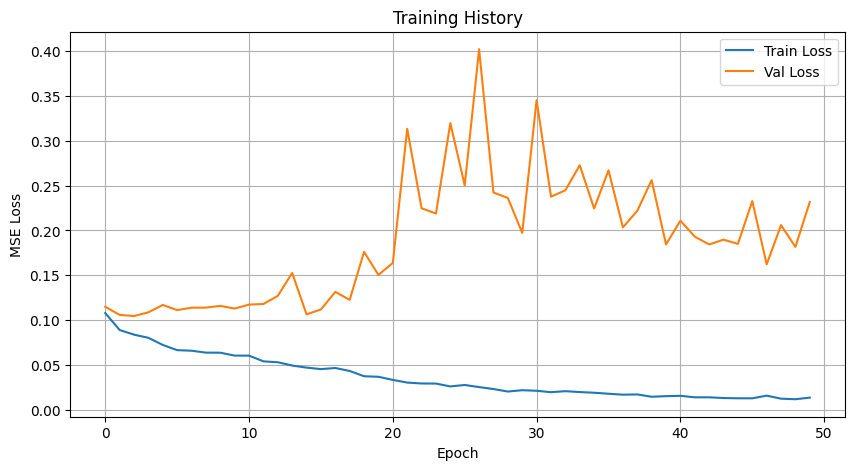

In [36]:
# Plot training history
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training History')
plt.legend()
plt.grid(True)

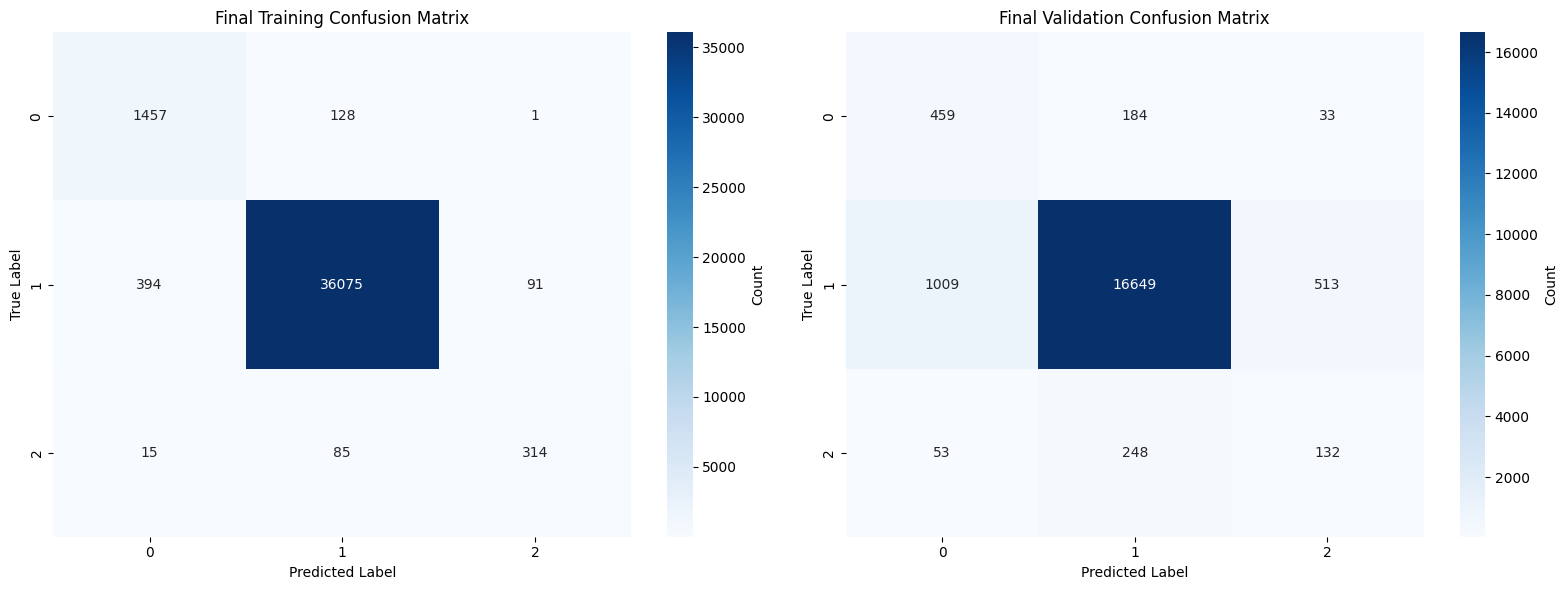


FINAL TRAINING METRICS
F1 Score: 0.9820
GMean Score: 0.9391

Per-class F1 Scores:
  Class 0: 0.8441
  Class 1: 0.9904
  Class 2: 0.7659

FINAL VALIDATION METRICS
F1 Score: 0.9102
GMean Score: 0.7507

Per-class F1 Scores:
  Class 0: 0.4178
  Class 1: 0.9446
  Class 2: 0.2376


In [37]:
# Generate final confusion matrices
model.eval()
final_train_preds = []
final_train_targets = []
final_val_preds = []
final_val_targets = []

with torch.no_grad():
    # Get final training predictions
    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        outputs = model(batch_X)
        preds = torch.argmax(outputs, dim=1)
        final_train_preds.extend(preds.cpu().numpy())
        final_train_targets.extend(batch_y.cpu().numpy())
    
    # Get final validation predictions
    for batch_X, batch_y in val_loader:
        batch_X = batch_X.to(device)
        outputs = model(batch_X)
        preds = torch.argmax(outputs, dim=1)
        final_val_preds.extend(preds.cpu().numpy())
        final_val_targets.extend(batch_y.cpu().numpy())

# Convert to numpy arrays
final_train_preds = np.array(final_train_preds)
final_train_targets = np.array(final_train_targets).ravel()
final_val_preds = np.array(final_val_preds)
final_val_targets = np.array(final_val_targets).ravel()

# Plot final confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Training confusion matrix
cm_train = confusion_matrix(final_train_targets, final_train_preds, labels=[0, 1, 2])
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[0, 1, 2], yticklabels=[0, 1, 2],
            ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_title('Final Training Confusion Matrix')

# Validation confusion matrix
cm_val = confusion_matrix(final_val_targets, final_val_preds, labels=[0, 1, 2])
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0, 1, 2], yticklabels=[0, 1, 2],
            ax=axes[1], cbar_kws={'label': 'Count'})
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
axes[1].set_title('Final Validation Confusion Matrix')

plt.tight_layout()
plt.show()

# Print classification reports
print("\n" + "="*50)
print("FINAL TRAINING METRICS")
print("="*50)
print(f"F1 Score: {f1_score(final_train_targets, final_train_preds, average='weighted'):.4f}")
print(f"GMean Score: {geometric_mean_score(final_train_targets, final_train_preds, average='weighted'):.4f}")
print("\nPer-class F1 Scores:")
for i, score in enumerate(f1_score(final_train_targets, final_train_preds, average=None)):
    print(f"  Class {i}: {score:.4f}")

print("\n" + "="*50)
print("FINAL VALIDATION METRICS")
print("="*50)
print(f"F1 Score: {f1_score(final_val_targets, final_val_preds, average='weighted'):.4f}")
print(f"GMean Score: {geometric_mean_score(final_val_targets, final_val_preds, average='weighted'):.4f}")
print("\nPer-class F1 Scores:")
for i, score in enumerate(f1_score(final_val_targets, final_val_preds, average=None)):
    print(f"  Class {i}: {score:.4f}")